# Exploratory Data Analysis: Website Phishing Dataset

## CS 418 - Checkpoint 3

In this notebook, it will explore the UCI Website Phishing dataset to identify patterns in phishing-related website features.

Our research question is:
**Which features of phishing links and webpages make them harder for people to recognize?**

We will examine feature distributions, missing values, anomalies, and relationships between website characteristics and phishing classifications.

In [1]:
import pandas as pd
from scipy.io import arff
from pathlib import Path

data_path = Path("../datasets/website-phishing/PhishingData.arff")

data, metadata = arff.loadarff(data_path)

df = pd.DataFrame(data)

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].str.decode("utf-8")

df.head()

,SFH,popUpWidnow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
0,1,-1,1,-1,-1,1,1,1,0,0
1,-1,-1,-1,-1,-1,0,1,1,1,1
2,1,-1,0,0,-1,0,-1,1,0,1
3,1,0,1,-1,-1,0,1,1,0,0
4,-1,-1,1,-1,0,0,-1,1,0,1


### 1. Dataset Profile
In this section, it examines the size, data types, missing values, and summary statistics of the UCI Phishing dataset.

In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe(include="all"))

Dataset Shape:
(1353, 10)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   SFH                1353 non-null   str  
 1   popUpWidnow        1353 non-null   str  
 2   SSLfinal_State     1353 non-null   str  
 3   Request_URL        1353 non-null   str  
 4   URL_of_Anchor      1353 non-null   str  
 5   web_traffic        1353 non-null   str  
 6   URL_Length         1353 non-null   str  
 7   age_of_domain      1353 non-null   str  
 8   having_IP_Address  1353 non-null   str  
 9   Result             1353 non-null   str  
dtypes: str(10)
memory usage: 123.5 KB

Missing Values:
SFH                  0
popUpWidnow          0
SSLfinal_State       0
Request_URL          0
URL_of_Anchor        0
web_traffic          0
URL_Length           0
age_of_domain        0
having_IP_Address    0
Result               0
dtype: int64

Summa

,SFH,popUpWidnow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
count,1353,1353,1353,1353,1353,1353,1353,1353,1353,1353
unique,3,3,3,3,3,3,3,2,2,3
top,1,0,1,-1,-1,0,0,1,0,-1
freq,767,639,751,617,610,473,563,825,1198,702


### Dataset Profile Findings

In the UCI Website Phishing, the dataset contains 1,353 rows and 10 columns, which includes nine phishing-related features, as well as one classification column (Result).

There are no missing values from this dataset. Although, all the columns were initially loaded as strings, even though the features use numerical codes like -1, 0, and 1.

In the dataset, it also has an odd distribution of classifications, with 702 phishing websites, 103 suspcious websites, and 548 legitimate websites.

Overvall, the dataset shows as completed, but the feature values need to be converted into numerical categories before continuing the analysis.

In [3]:
df = df.astype(int)

print("Duplicate rows:", df.duplicated().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nUnique values by column:")
for col in df.columns:
    print(col, sorted(df[col].unique()))

print("\nUpdated data types:")
print(df.dtypes)

Duplicate rows: 629

Total missing values: 0

Unique values by column:
SFH [np.int64(-1), np.int64(0), np.int64(1)]
popUpWidnow [np.int64(-1), np.int64(0), np.int64(1)]
SSLfinal_State [np.int64(-1), np.int64(0), np.int64(1)]
Request_URL [np.int64(-1), np.int64(0), np.int64(1)]
URL_of_Anchor [np.int64(-1), np.int64(0), np.int64(1)]
web_traffic [np.int64(-1), np.int64(0), np.int64(1)]
URL_Length [np.int64(-1), np.int64(0), np.int64(1)]
age_of_domain [np.int64(-1), np.int64(1)]
having_IP_Address [np.int64(0), np.int64(1)]
Result [np.int64(-1), np.int64(0), np.int64(1)]

Updated data types:
SFH                  int64
popUpWidnow          int64
SSLfinal_State       int64
Request_URL          int64
URL_of_Anchor        int64
web_traffic          int64
URL_Length           int64
age_of_domain        int64
having_IP_Address    int64
Result               int64
dtype: object


### Anomaly Detection Findings
After checking the dataset, I found 629 duplicate rows and no missing values. All 1,353 rows initially contained string values, so I converted the columns into integers to make them easier to analyze. 

Some of the features contain categorical codes such as -1, 0, and 1. I did not find values that are outside these codes, although the valid categoires still need to be reviewed against the dataset documentation.

I have decided to keep the duplicate rows because multiple websites could potentially share the same phishing related characteristics. However, I did flag them as posssible limitations since the dataset does not include individual website IDs to verify if they are actually duplicate observations.

Matplotlib is building the font cache; this may take a moment.


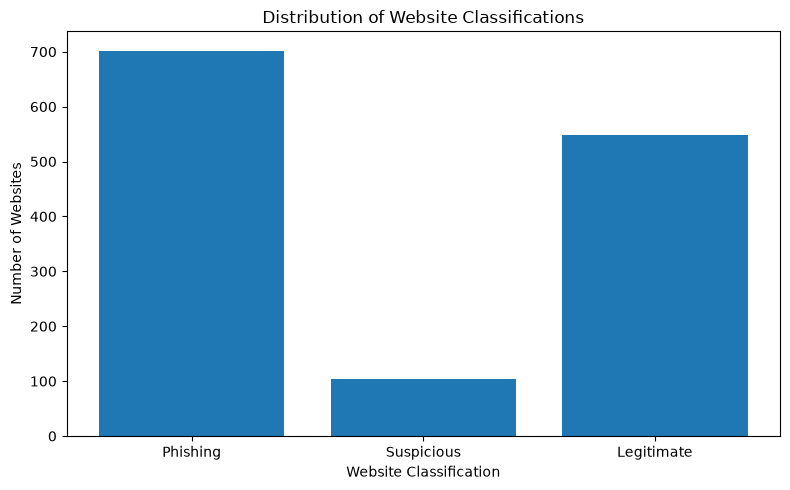

In [4]:
import matplotlib.pyplot as plt

result_counts = df["Result"].value_counts().reindex([-1, 0, 1], fill_value=0)

labels = ["Phishing", "Suspicious", "Legitimate"]

plt.figure(figsize=(8, 5))
plt.bar(labels, result_counts.values)

plt.title("Distribution of Website Classifications")
plt.xlabel("Website Classification")
plt.ylabel("Number of Websites")

plt.tight_layout()
plt.show()

### Distribution of Website Classifications

In the graph above, it shows that phishing websites make up the largest category with 702 observations, followed by 548 legitimate websites and 103 suspicious websites. In the dataset, it contains the least amount of suspicious websites compared to the other two categories. This is important because the smaller number of suspicious websites may make it harder to identify patterns for that group.

This graph gives us a starting point for comparing phishing-related features across the three classifications.

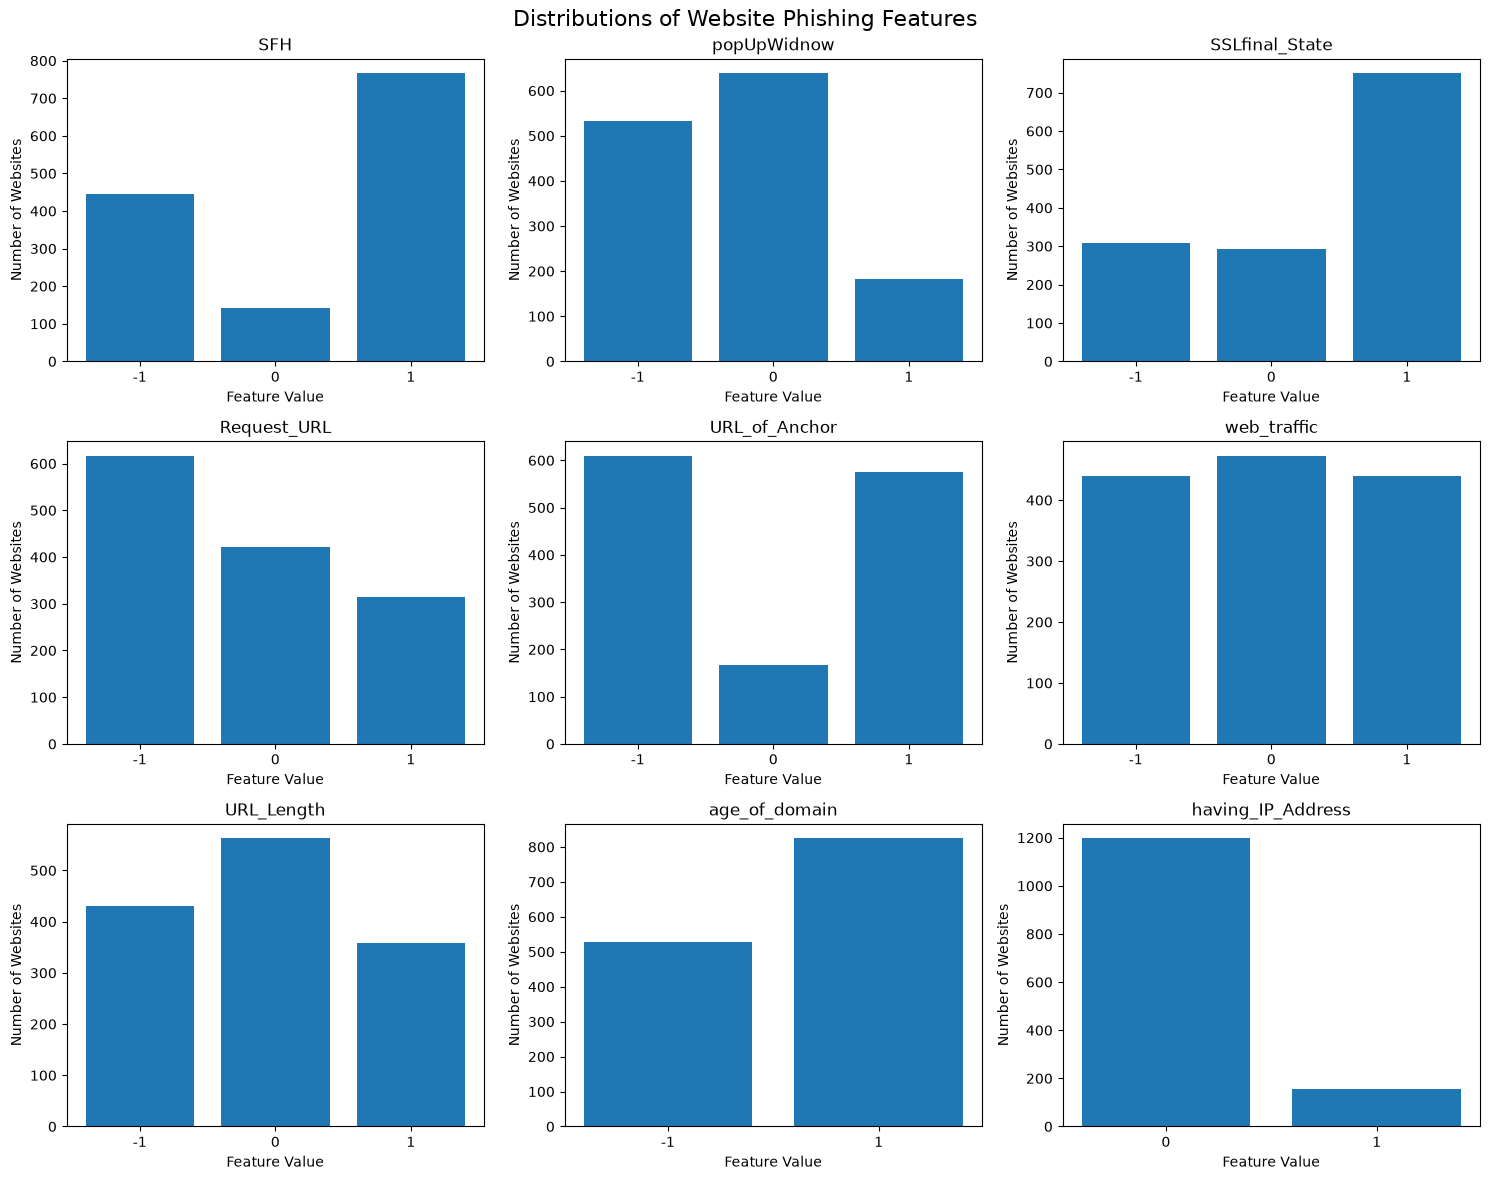

In [5]:
features = [col for col in df.columns if col != "Result"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flat, features):
    counts = df[feature].value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(feature)
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Number of Websites")

plt.suptitle("Distributions of Website Phishing Features", fontsize=16)
plt.tight_layout()
plt.show()

### Distribution of Phishing Features
In the graph, it shows how the nine phishing-related features are distributed across the 1,353 websites. Some features have odd distributions. An example of this would be: having_IP_Address is mostly 0, while SSLfinal_State and SFH have more observations with a value of 1.

Other features, such as web_traffic have a more even distribution across their categories. URL_of_Anchor also stands out because values -1 and 1 are much more than commmon than 0. 

These findings show that some website characteristics appear more often than others. But, we still need to compare them with the website classifications to determine whether they are associated with phishing.

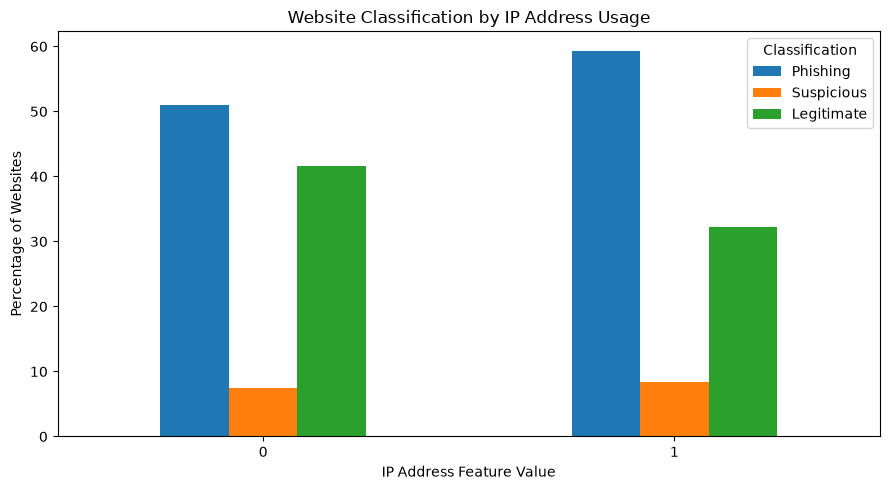

In [6]:
# this is the relationship between IP address usage and website classification
ip_result = pd.crosstab(
    df["having_IP_Address"],
    df["Result"],
    normalize="index"
) * 100

ip_result = ip_result.reindex(columns=[-1, 0, 1], fill_value=0)

ip_result.columns = ["Phishing", "Suspicious", "Legitimate"]
ip_result.index = ip_result.index.astype(str)

ip_result.plot(kind="bar", figsize=(9, 5))

plt.title("Website Classification by IP Address Usage")
plt.xlabel("IP Address Feature Value")
plt.ylabel("Percentage of Websites")
plt.xticks(rotation=0)
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

### Relationship 1: IP Address Feature vs. Website Classification

What the graph shows:

Websites with an IP address feature value of 1 have a higher percentage of phishing classifications (about 59%) compared to websites with a value of 0 (about 51%).

So what?:

This potentially means that the IP address feature may be associated with whether a website is classified as phishing. This pattern is somewhat expected because unusual URL characteristics can be signs of phishing. However, both groups still contain legitimate websites, so this feature alone is not enough to identify phishing.

What next?:

Next, we could compare the IP address feature with other characteristics, such as SSL status or URL length, to see whether combining multiple features helps distinguish phishing websites from legitimate ones. We should also compare this finding with our primary phishing dataset.

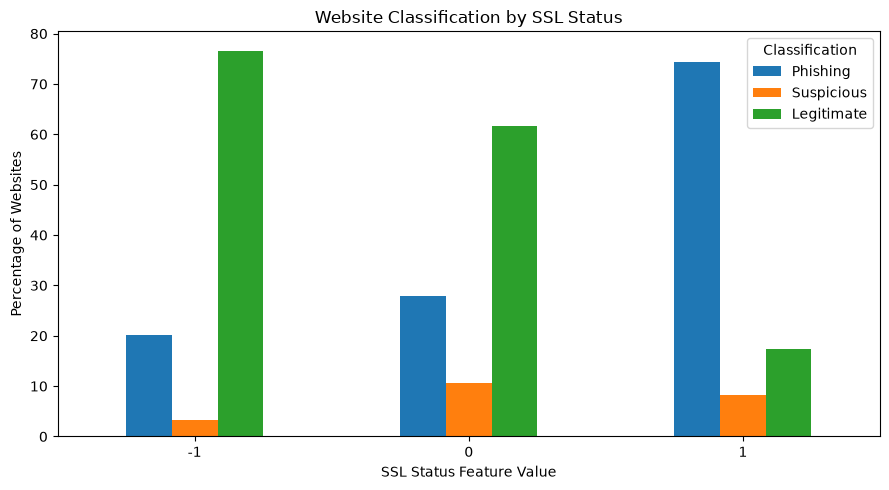

In [7]:
# here lies the relationship between SSL status and website classification
ssl_result = pd.crosstab(
    df["SSLfinal_State"],
    df["Result"],
    normalize="index"
) * 100

ssl_result = ssl_result.reindex(
    index=[-1, 0, 1],
    columns=[-1, 0, 1],
    fill_value=0
)

ssl_result.columns = ["Phishing", "Suspicious", "Legitimate"]
ssl_result.index = ssl_result.index.astype(str)

ssl_result.plot(kind="bar", figsize=(9, 5))

plt.title("Website Classification by SSL Status")
plt.xlabel("SSL Status Feature Value")
plt.ylabel("Percentage of Websites")
plt.xticks(rotation=0)
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

### Relationship 2: SSL Status vs. Website Classification

What the graph shows:

The graph shows a big difference in website classifications depending on SSL status. Around 74% of websites with an SSL feature value of 1 are classified as phishing, compared to about 20% of websites with a value of -1.

So what?:

This potentially means that SSL status is strongly associated with phishing classification in this dataset. The difference was interesting because it is much larger than the difference observed in the IP address comparison. But, we need to confirm what the SSL category values represent before drawing conclusions about website security.

What next?:

Next, we could compare SSL status with other phishing indicators, such as URL length or domain age, to see whether these characteristics show similar patterns. We could also see whether this relationship appears in our primary phishing dataset.

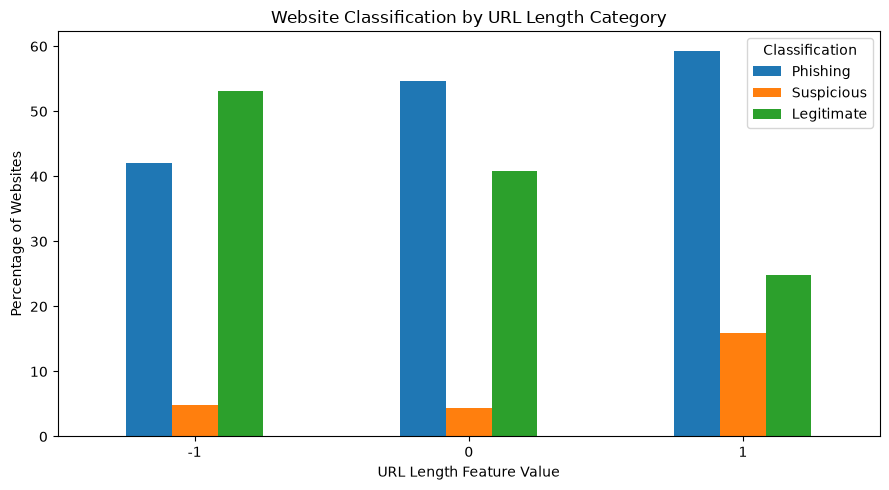

In [8]:
# here lies the relationship between URL length and website classification

length_result = pd.crosstab(
    df["URL_Length"],
    df["Result"],
    normalize="index"
) * 100

length_result = length_result.reindex(
    index=[-1, 0, 1],
    columns=[-1, 0, 1],
    fill_value=0
)

length_result.columns = ["Phishing", "Suspicious", "Legitimate"]
length_result.index = length_result.index.astype(str)

length_result.plot(kind="bar", figsize=(9, 5))

plt.title("Website Classification by URL Length Category")
plt.xlabel("URL Length Feature Value")
plt.ylabel("Percentage of Websites")
plt.xticks(rotation=0)
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

### Relationship 3: URL Length vs. Website Classification

What the graph shows:

In this graph, it shows that website classification differs across URL length categories. Around 42% of websites in category -1 are classified as phishing, compared to about 55% in category 0 and 59% in category 1.

So what?:

This potentially means that URL length categories may be associated with phishing classification. The pattern was somewhat expected because unusual URL structures can be common in phishing websites. But, the dataset uses categorical codes instead of actual URL lengths, so we need to verify what each category represents before drawing conclusions about longer or shorter URLs.

What next?:

Next, we could compare URL length with other phishing signs, such as SSL status and domain age, to see if combining these characteristics reveals stronger patterns. We could also compare the URL length findings against our primary PhiUSIIL dataset to see if the relationship is consistent across both datasets.

## 4. Comparison with Primary Dataset

In this section, we will compare URL length and phishing classification patterns between the UCI Website Phishing secondary dataset and the PhiUSIIL Phishing URL dataset.

Since the datasets represent URL length differently, we will analyze them separately and compare their patterns rather than directly joining observations.

In [9]:
primary_path = Path("../datasets/PhiUSIIL_Phishing_URL_Dataset.csv")

primary_df = pd.read_csv(primary_path)

print("Primary Dataset Shape:")
print(primary_df.shape)

print("\nPrimary Dataset Columns:")
print(primary_df.columns.tolist())

display(primary_df.head())

Primary Dataset Shape:
(235795, 56)

Primary Dataset Columns:
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [10]:
# checking classification counts in the primary dataset
print("Primary Dataset Classification Counts:")
print(primary_df["label"].value_counts().sort_index())

# checking URL length statistics by classification
print("\nURL Length Statistics by Classification:")
display(primary_df.groupby("label")["URLLength"].describe())

Primary Dataset Classification Counts:
label
0    100945
1    134850
Name: count, dtype: int64

URL Length Statistics by Classification:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,45.720293,61.145523,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


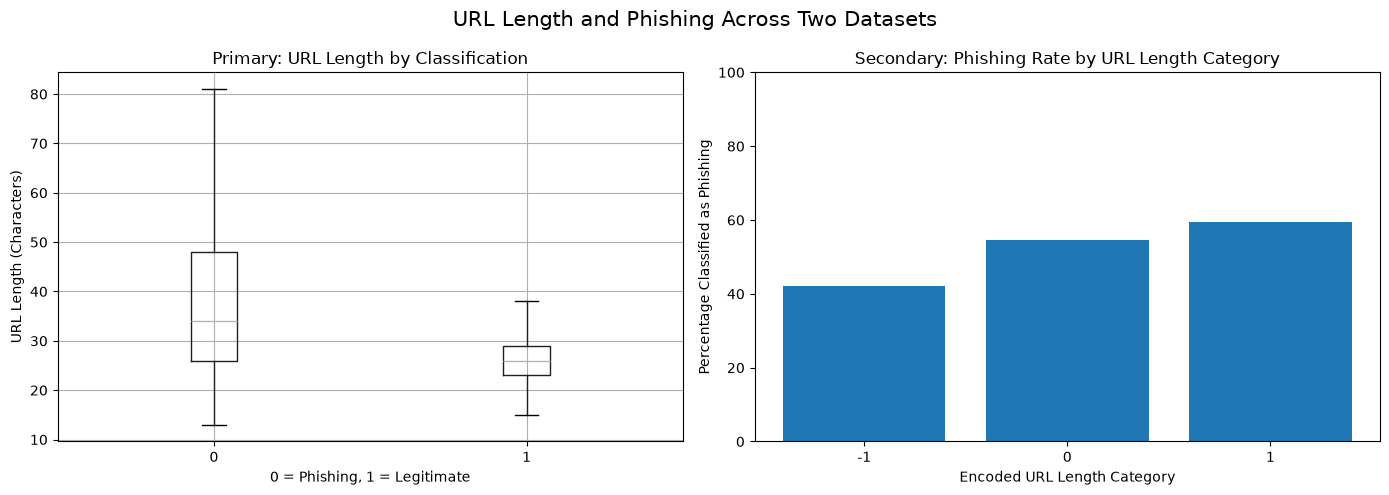

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

primary_df.boxplot(
    column="URLLength",
    by="label",
    ax=axes[0],
    showfliers=False
)

axes[0].set_title("Primary: URL Length by Classification")
axes[0].set_xlabel("0 = Phishing, 1 = Legitimate")
axes[0].set_ylabel("URL Length (Characters)")

secondary_rates = (
    df.groupby("URL_Length")["Result"]
    .apply(lambda x: (x == -1).mean() * 100)
    .reindex([-1, 0, 1])
)

axes[1].bar(
    secondary_rates.index.astype(str),
    secondary_rates.values
)

axes[1].set_title("Secondary: Phishing Rate by URL Length Category")
axes[1].set_xlabel("Encoded URL Length Category")
axes[1].set_ylabel("Percentage Classified as Phishing")
axes[1].set_ylim(0, 100)

plt.suptitle("URL Length and Phishing Across Two Datasets", fontsize=15)
plt.tight_layout()
plt.show()

### Cross-Dataset Comparison Findings

What the graph shows:

In the primary PhiUSIIL dataset, it shows that phishing websites usually have longer URLs than legitimate websites. The median phishing URL length is 34 characters, compared to 26 characters for legitimate websites.

In the secondary Website Phishing dataset, it also shows differences in phishing classification across URL length categories. Phishing classifications increase from approximately 42% in category -1 to 59% in category 1.

So what?:

Both datasets show that URL length-related features are associated with phishing classification. This pattern was somewhat expected because phishing websites may use unusual URL structures. But, the datasets measure URL length differently, so the results cannot be directly compared numerically.

What next?:

Next, we could examine whether other features, such as SSL status and IP address usage, show similar patterns across both datasets. We could also investigate if combining multiple features is more useful for identifying phishing websites than relying on URL length alone.